In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import ast
#plt.rcParams['font.family'] = 'AppleGothic'    # Mac
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
plt.rcParams['axes.unicode_minus'] = False

reviews = pd.read_csv("../../../../data/preprocessed/steam_indie_reviews.csv")
df = pd.read_csv('../../../../data/preprocessed/steam_indie_genre_stratified_sample.csv')

리뷰에 장르 추가

In [2]:
genre_info = df[["appid", "primary_genre"]].drop_duplicates()

In [3]:
reviews_merged = reviews.merge(
    genre_info,
    on="appid",
    how="left"
)

In [4]:
reviews_merged['primary_genre'].value_counts()

primary_genre
RPG           51022
Sports        32900
Adventure     22020
Casual        16076
Action        15578
Strategy      14459
Simulation     9234
Racing         5096
Name: count, dtype: int64

In [5]:
reviews = reviews_merged

In [6]:
reviews.T

,0,1,2,3,4,5,6,7,8,9,...,166375,166376,166377,166378,166379,166380,166381,166382,166383,166384
recommendationid,18698790,18699465,18699648,18700348,18701774,18701783,18702904,18707357,18712302,18714961,...,201425933,201447607,202724029,204448566,204532084,204593298,205146375,216117623,218587813,222468669
appid,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,...,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160
language,french,english,english,english,english,schinese,english,english,english,english,...,english,english,english,english,spanish,english,english,english,russian,english
review,good game for this price,"BGM - GOOD \nGRAPHICS - GOOD\n\nBut, Slip effe...","this game is like a zen-garden, I love it! \n\...",Ever played Bhop? Surf? If so this games mecha...,It's Lit,这个游戏无聊的时候玩玩也蛮好的，只是玩的时间一长就容易很烦\n也就值这个价钱吧,"Greatness comes in all sorts of things, but th...",Don't buy this game. The platforms you jump on...,Enjoying this game [b]SO MUCH[/b] !,I agree with the other reviews which praise th...,...,Pure 10/10 emotional storm: total frustration ...,"If this game excels at one thing, it’s making ...","I will truly ""READ"" the game description next ...",I don’t usually review games but this one dese...,He jugado MUCHOS juegos de salas de escape y n...,"We glitched out once, had to restart the level...",Had an issue with the lighting being too dark ...,It is the worst of the Mad Experiments games.\...,"Нормас, на пострадать ♥♥♥♥♥♥ - пойдёт.","Glitches, bad puzzles, text not leaving screen..."
timestamp_created,1445883033,1445885616,1445886217,1445889159,1445895144,1445895178,1445899986,1445929789,1445959527,1445969901,...,1754305413,1754328332,1755963658,1757987540,1758089096,1758162903,1758780243,1768605218,1771374165,1775282996
timestamp_updated,1445883033,1445885616,1482541338,1445895001,1445895144,1445895178,1445903284,1445999928,1445959527,1445969901,...,1754305413,1754328627,1755963658,1757987602,1758089179,1758162903,1758780243,1768605218,1771374165,1775282996
voted_up,True,True,True,True,True,True,True,False,True,True,...,True,True,False,True,False,True,True,False,True,False
votes_up,2,1,5,16,4,0,3,8,1,12,...,0,0,4,0,2,0,0,0,0,0
votes_funny,1,0,0,0,0,0,1,0,0,23,...,0,0,0,0,0,0,0,0,0,0
weighted_vote_score,0.52381,0.421372,0.500076,0.637511,0.49581,0.5,0.469881,0.300778,0.471092,0.553418,...,0.5,0.5,0.586466,0.5,0.543568,0.5,0.5,0.5,0.5,0.5


In [7]:
reviews.isna().sum()

recommendationid                 0
appid                            0
language                         0
review                           0
timestamp_created                0
timestamp_updated                0
voted_up                         0
votes_up                         0
votes_funny                      0
weighted_vote_score              0
comment_count                    0
steam_purchase                   0
received_for_free                0
written_during_early_access      0
author_steamid                   0
author_num_games_owned           0
author_num_reviews               0
author_last_played               0
created_date                     0
updated_date                     0
author_last_played_date          0
playtime_forever_hours           0
playtime_last_two_weeks_hours    0
playtime_at_review_hours         2
primary_genre                    0
dtype: int64

긍정리뷰 부정리뷰 뽑기

In [8]:
reviews["sentiment"] = reviews["voted_up"].map({
    True: "positive",
    False: "negative"
})

reviews[["appid", "language", "review", "voted_up", "sentiment"]].head()

,appid,language,review,voted_up,sentiment
0,324470,french,good game for this price,True,positive
1,324470,english,"BGM - GOOD \nGRAPHICS - GOOD\n\nBut, Slip effe...",True,positive
2,324470,english,"this game is like a zen-garden, I love it! \n\...",True,positive
3,324470,english,Ever played Bhop? Surf? If so this games mecha...,True,positive
4,324470,english,It's Lit,True,positive


In [9]:
#나라별 리뷰수 카운트 하기

일단 영어리뷰만 뽑기

In [10]:
reviews.T

,0,1,2,3,4,5,6,7,8,9,...,166375,166376,166377,166378,166379,166380,166381,166382,166383,166384
recommendationid,18698790,18699465,18699648,18700348,18701774,18701783,18702904,18707357,18712302,18714961,...,201425933,201447607,202724029,204448566,204532084,204593298,205146375,216117623,218587813,222468669
appid,324470,324470,324470,324470,324470,324470,324470,324470,324470,324470,...,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160,3683160
language,french,english,english,english,english,schinese,english,english,english,english,...,english,english,english,english,spanish,english,english,english,russian,english
review,good game for this price,"BGM - GOOD \nGRAPHICS - GOOD\n\nBut, Slip effe...","this game is like a zen-garden, I love it! \n\...",Ever played Bhop? Surf? If so this games mecha...,It's Lit,这个游戏无聊的时候玩玩也蛮好的，只是玩的时间一长就容易很烦\n也就值这个价钱吧,"Greatness comes in all sorts of things, but th...",Don't buy this game. The platforms you jump on...,Enjoying this game [b]SO MUCH[/b] !,I agree with the other reviews which praise th...,...,Pure 10/10 emotional storm: total frustration ...,"If this game excels at one thing, it’s making ...","I will truly ""READ"" the game description next ...",I don’t usually review games but this one dese...,He jugado MUCHOS juegos de salas de escape y n...,"We glitched out once, had to restart the level...",Had an issue with the lighting being too dark ...,It is the worst of the Mad Experiments games.\...,"Нормас, на пострадать ♥♥♥♥♥♥ - пойдёт.","Glitches, bad puzzles, text not leaving screen..."
timestamp_created,1445883033,1445885616,1445886217,1445889159,1445895144,1445895178,1445899986,1445929789,1445959527,1445969901,...,1754305413,1754328332,1755963658,1757987540,1758089096,1758162903,1758780243,1768605218,1771374165,1775282996
timestamp_updated,1445883033,1445885616,1482541338,1445895001,1445895144,1445895178,1445903284,1445999928,1445959527,1445969901,...,1754305413,1754328627,1755963658,1757987602,1758089179,1758162903,1758780243,1768605218,1771374165,1775282996
voted_up,True,True,True,True,True,True,True,False,True,True,...,True,True,False,True,False,True,True,False,True,False
votes_up,2,1,5,16,4,0,3,8,1,12,...,0,0,4,0,2,0,0,0,0,0
votes_funny,1,0,0,0,0,0,1,0,0,23,...,0,0,0,0,0,0,0,0,0,0
weighted_vote_score,0.52381,0.421372,0.500076,0.637511,0.49581,0.5,0.469881,0.300778,0.471092,0.553418,...,0.5,0.5,0.586466,0.5,0.543568,0.5,0.5,0.5,0.5,0.5


In [11]:
reviews_en = reviews[
    (reviews["language"] == "english") &
    (reviews["review"].notna())
].copy()

reviews_en.shape

(72268, 26)

긍정리뷰 부정리뷰 샘플 추출

In [12]:
positive_sample = reviews_en[reviews_en["voted_up"] == True].sample(
    20,
    random_state=42
)

negative_sample = reviews_en[reviews_en["voted_up"] == False].sample(
    20,
    random_state=42
)

review_sample = pd.concat([positive_sample, negative_sample])

review_sample[["sentiment", "review"]].head()

,sentiment,review
15895,positive,A fun golf game to play around with your frien...
100077,positive,A Great Start for Non-Horror Fans and a Solid ...
120950,positive,i really would love to see more story within t...
76772,positive,"This game needs a better, more clear upgrade t..."
111545,positive,I played the demo religiously before the full ...


In [13]:
reviews.groupby("voted_up")["playtime_forever_hours"].median()

#True는 긍정
#False는 부정

voted_up
False     4.800000
True     11.566667
Name: playtime_forever_hours, dtype: float64

긍정리뷰를 남긴 사람이 전반적으로 플레이 타임이 길었다

심층분석

필요한 컬럼만 추출

In [14]:
reviews[[
    "appid",
    "language",
    "review",
    "sentiment",
    "playtime_forever_hours",
    "timestamp_created"
]].head()

,appid,language,review,sentiment,playtime_forever_hours,timestamp_created
0,324470,french,good game for this price,positive,3.483333,1445883033
1,324470,english,"BGM - GOOD \nGRAPHICS - GOOD\n\nBut, Slip effe...",positive,0.216667,1445885616
2,324470,english,"this game is like a zen-garden, I love it! \n\...",positive,13.616667,1445886217
3,324470,english,Ever played Bhop? Surf? If so this games mecha...,positive,7.483333,1445889159
4,324470,english,It's Lit,positive,8.666667,1445895144


긍정과 부정의 비율 보기

In [15]:
sentiment_ratio = reviews["sentiment"].value_counts(normalize=True) * 100
sentiment_ratio.round(2)

sentiment
positive    91.93
negative     8.07
Name: proportion, dtype: float64

전체적으로 긍정의 리뷰 비율이 높음

리뷰의 길이

In [16]:
reviews["review_length"] = reviews["review"].astype(str).str.len()

reviews[["review", "sentiment", "review_length"]].head()

,review,sentiment,review_length
0,good game for this price,positive,24
1,"BGM - GOOD \nGRAPHICS - GOOD\n\nBut, Slip effe...",positive,119
2,"this game is like a zen-garden, I love it! \n\...",positive,387
3,Ever played Bhop? Surf? If so this games mecha...,positive,1100
4,It's Lit,positive,8


긍정과 부정의 리뷰의 길이를 봐보자

In [17]:
length_summery = (
    reviews.groupby('sentiment')['review_length']
    .describe()
)
length_summery

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,13421.0,353.073169,726.584328,1.0,33.0,110.0,343.0,8000.0
positive,152964.0,171.034753,428.265546,1.0,13.0,45.0,148.0,8000.0


대체적으로 부정리뷰의 길이가 더 긴것을 확인할 수있음

중앙값으로 봐보면

In [18]:
reviews.groupby('sentiment')['review_length'].median()

sentiment
negative    110.0
positive     45.0
Name: review_length, dtype: float64

** 즉 부정적인 리뷰를 남긴 유저가 좀더 자세한 리뷰를 남겻을 가능성을 보임

리뷰 길이 시각화

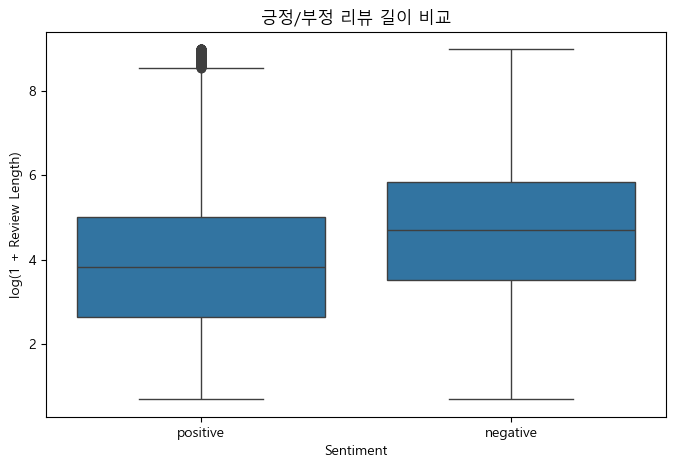

In [19]:
reviews["log_review_length"] = np.log1p(reviews["review_length"])

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=reviews,
    x="sentiment",
    y="log_review_length"
)

plt.title("긍정/부정 리뷰 길이 비교")
plt.xlabel("Sentiment")
plt.ylabel("log(1 + Review Length)")
plt.show()

플레이 타임을 전처리

In [20]:
reviews["playtime_hours"] = (reviews["playtime_forever_hours"] / 60).round(2)

reviews[["playtime_forever_hours", "playtime_hours"]].head()

,playtime_forever_hours,playtime_hours
0,3.483333,0.06
1,0.216667,0.00
2,13.616667,0.23
3,7.483333,0.12
4,8.666667,0.14


긍정과 부정별 플레이타임 비교

In [21]:
playtime_summary = (
    reviews.groupby("sentiment")["playtime_hours"]
    .describe()
)

playtime_summary

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,13421.0,0.319460,1.155147,0.0,0.02,0.08,0.24,45.04
positive,152964.0,0.519298,2.702912,0.0,0.10,0.19,0.41,505.75


중앙값만 보기

In [22]:
reviews.groupby("sentiment")["playtime_hours"].median()

sentiment
negative    0.08
positive    0.19
Name: playtime_hours, dtype: float64

플레이 타임의 극단값이 너무 커서 로그변환 진행 후 시각화

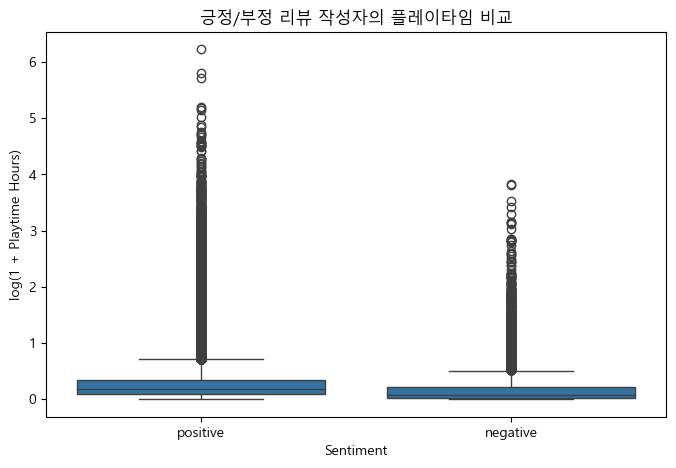

In [23]:
reviews["log_playtime_hours"] = np.log1p(reviews["playtime_hours"])

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=reviews,
    x="sentiment",
    y="log_playtime_hours"
)

plt.title("긍정/부정 리뷰 작성자의 플레이타임 비교")
plt.xlabel("Sentiment")
plt.ylabel("log(1 + Playtime Hours)")
plt.show()

언어의 분포 확인

In [24]:
language_summary = (
    reviews["language"]
    .value_counts()
    .reset_index()
)

language_summary.columns = ["language", "review_count"]
language_summary.head(20)

,language,review_count
0,english,72268
1,schinese,38644
2,russian,15898
3,spanish,9269
4,german,5762
5,brazilian,4167
6,french,4056
7,japanese,2756
8,tchinese,2643
9,koreana,2548


시각화

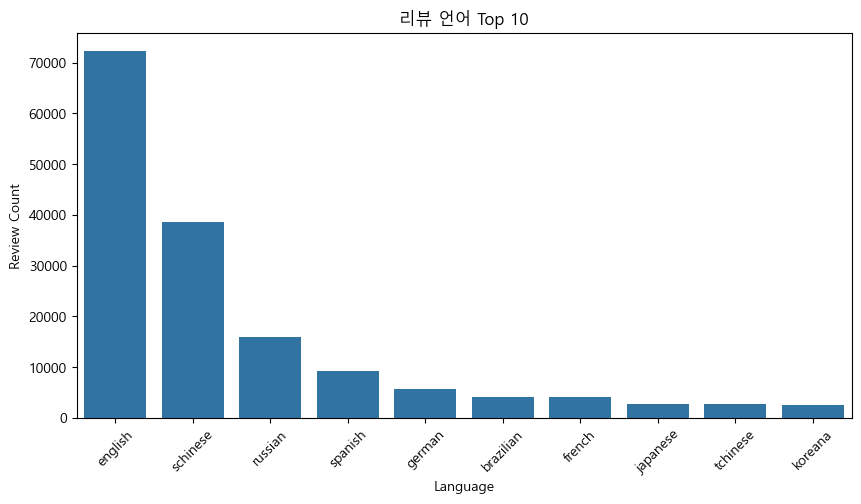

In [25]:
top_lang = reviews["language"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_lang.index,
    y=top_lang.values
)

plt.title("리뷰 언어 Top 10")
plt.xlabel("Language")
plt.ylabel("Review Count")
plt.xticks(rotation=45)
plt.show()

언어별 긍정율 비율

In [26]:
lang_sentiment = (
    reviews.groupby("language")
    .agg(
        review_count=("review", "count"),
        positive_ratio=("voted_up", "mean")
    )
    .sort_values("review_count", ascending=False)
)

lang_sentiment.head(20)

,review_count,positive_ratio
language,,
english,72268,0.921597
schinese,38644,0.910956
russian,15898,0.914014
spanish,9269,0.951451
german,5762,0.919299
brazilian,4167,0.961123
french,4056,0.933679
japanese,2756,0.826923
tchinese,2643,0.894816


언어는 너무다양하기때문에 50개이상의 리뷰가 있는 리뷰만봐보자

In [27]:
lang_sentiment_30 = lang_sentiment[
    lang_sentiment["review_count"] >= 50
].copy()

lang_sentiment_30 = lang_sentiment_30.sort_values("positive_ratio", ascending=False)

시각화

리뷰 언어별 긍정율

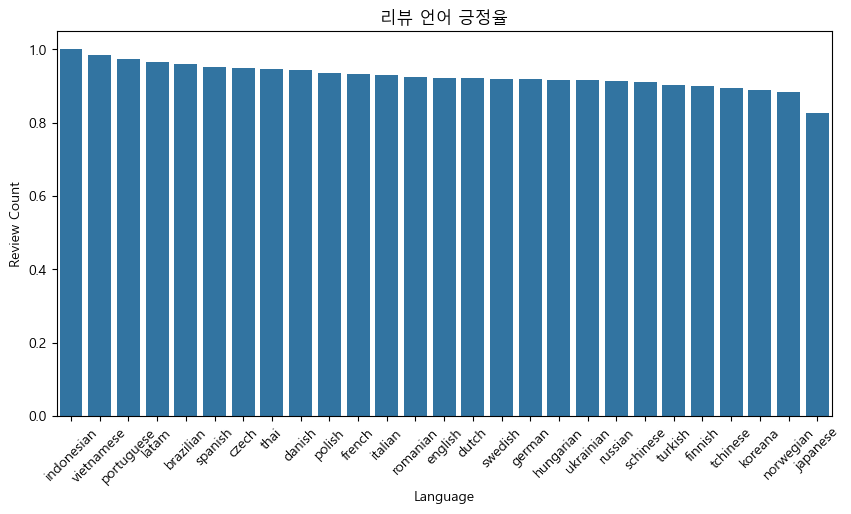

In [28]:
pos_ratio = lang_sentiment_30

plt.figure(figsize=(10, 5))
sns.barplot(data = pos_ratio , x = 'language',y = 'positive_ratio')

plt.title("리뷰 언어 긍정율")
plt.xlabel("Language")
plt.ylabel("Review Count")
plt.xticks(rotation=45)
plt.show()

시간칼럼 변화

In [29]:
reviews["created_date"] = pd.to_datetime(
    reviews["timestamp_created"],
    unit="s",
    errors="coerce"
)

reviews["created_month"] = reviews["created_date"].dt.to_period("M").astype(str)

reviews[["timestamp_created", "created_date", "created_month"]].head()

,timestamp_created,created_date,created_month
0,1445883033,2015-10-26 18:10:33,2015-10
1,1445885616,2015-10-26 18:53:36,2015-10
2,1445886217,2015-10-26 19:03:37,2015-10
3,1445889159,2015-10-26 19:52:39,2015-10
4,1445895144,2015-10-26 21:32:24,2015-10


In [30]:
monthly_review = (
    reviews.groupby("created_month")
    .agg(
        review_count=("review", "count"),
        positive_ratio=("voted_up", "mean")
    )
    .reset_index()
)

monthly_review.head()

,created_month,review_count,positive_ratio
0,2015-10,18,0.888889
1,2015-11,14,1.000000
2,2015-12,18,0.833333
3,2016-01,8,0.500000
4,2016-02,8,0.750000


전체 리뷰 중 긍정 리뷰 비율은 약 91.93%로 나타났다.
부정 리뷰는 긍정 리뷰보다 리뷰 길이 중앙값이 길었고, 이는 불만 유저가 더 구체적인 문제를 작성했을 가능성을 보여준다.
플레이타임 기준으로는 긍정 리뷰 작성자의 중앙 플레이타임이 더 높았다.
언어별로는 영어 리뷰가 가장 많았으며, 리뷰 수 50개 이상 언어 중 인도네시아 언어의 긍정 비율이 가장 높았다.

## 긍정리뷰와 부정리뷰 키워드 분석

영어로 작성된 리뷰로 먼저 확인작업 진행

전처리

In [31]:
reviews_en = reviews[
    (reviews["language"] == "english") &
    (reviews["review"].notna())
].copy()

print(reviews_en.shape)
reviews_en[["review", "sentiment"]].head()

(72268, 31)


,review,sentiment
1,"BGM - GOOD \nGRAPHICS - GOOD\n\nBut, Slip effe...",positive
2,"this game is like a zen-garden, I love it! \n\...",positive
3,Ever played Bhop? Surf? If so this games mecha...,positive
4,It's Lit,positive
6,"Greatness comes in all sorts of things, but th...",positive


In [32]:
import re
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

reviews_en["clean_review"] = reviews_en["review"].apply(clean_text)

reviews_en[["review", "clean_review"]].head()

,review,clean_review
1,"BGM - GOOD \nGRAPHICS - GOOD\n\nBut, Slip effe...",bgm good graphics good but slip effect is too ...
2,"this game is like a zen-garden, I love it! \n\...",this game is like a zen garden i love it pros ...
3,Ever played Bhop? Surf? If so this games mecha...,ever played bhop surf if so this games mechani...
4,It's Lit,it s lit
6,"Greatness comes in all sorts of things, but th...",greatness comes in all sorts of things but thi...


불용어 제거후 단어 빈도 확인

In [33]:
# from sklearn.feature_extraction.text import CountVectorizer

# stop_words = [
#     # 기본 영어
#     "the","and","is","it","to","of","a","in","for","this","that","you",
#     "with","on","as","are","was","but","be","have","not","so","if","at",
#     "by","an","or","from","they","we","he","she","them","his","her","our",
#     "their","its","who","what","which","when","where","why","how",

#     # 대명사/지시어
#     "i","me","my","mine","your","yours","our","ours","their","theirs",
#     "him","herself","himself","ourselves","themselves",

#     # 일반 동사 (의미 약함)
#     "get","got","make","made","go","went","take","took","use","used",
#     "try","tried","give","gave","come","came","want","wanted",
#     "see","seen","look","looked","find","found","think","thought",
#     "know","knew","keep","kept","put","set","run","ran",

#     # 시간/수량
#     "one","two","three","first","second","many","much","lot","lots",
#     "few","some","any","every","each","all",
#     "time","times","hour","hours","day","days","week","weeks","month","months",

#     # 게임 리뷰 흔한 단어
#     "game","games","play","playing","played","player","players",
#     "thing","things","way","something","anything","everything",
#     "stuff","part","parts","experience",

#     # 평가 표현 (너무 일반적)
#     "good","bad","great","nice","fun","boring","awesome","amazing",
#     "love","like","liked","hate","dislike","recommend","recommended",
#     "best","worst","better","worse","cool","enjoy","enjoyed",

#     # 강도/정도 표현
#     "really","very","pretty","quite","too","so","just","even","still",
#     "well","almost","maybe","probably","definitely","actually",

#     # 부정/축약형
#     "im","ive","dont","didnt","cant","couldnt","would","should",
#     "wasnt","werent","isnt","arent","doesnt","hadnt","hasnt","havent",

#     # 기타 잡단어
#     "yes","no","ok","okay","uh","um",
#     "etc","etc.","lol","haha","yeah","yep",

#     # 리뷰에서 흔히 나오는 무의미 단어
#     "edit","update","review","reviews","steam","pc","version","patch",
#     "dev","developer","devs","support","thanks",

#     # 숫자/단위 관련
#     "10","20","30","100","1000",
#     "fps","gb","mb"
# ]
    

# def get_top_words(data, sentiment_value, n=30):
#     text_data = data[data["sentiment"] == sentiment_value]["clean_review"]
    
#     vectorizer = CountVectorizer(
#         stop_words=stop_words,
#         min_df=3
#     )
    
#     word_matrix = vectorizer.fit_transform(text_data)
    
#     word_counts = word_matrix.sum(axis=0).A1
#     words = vectorizer.get_feature_names_out()
    
#     result = pd.DataFrame({
#         "word": words,
#         "count": word_counts
#     }).sort_values("count", ascending=False)
    
#     return result.head(n)

# positive_words = get_top_words(reviews_en, "positive", 30)
# negative_words = get_top_words(reviews_en, "negative", 30)

# positive_words

불용어를 아무리 추가해도 노이즈 자꾸 나옴 
방식변경 => TF-IDF방식
많이나오는 단어는 중요할 수 있어 가산점을 주지만 모든 곳에서 많이나온다면 의미가 없다고 판단하여 페널티를줘서
진짜 중요한 단어를 뽑아오는 기법

한개 단어만 보면 노이즈가 많을 가능성이 높기때문에 2단어 조합으로 보기

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [35]:
def get_tfidf_bigrams(data, sentiment_value, n=100):
    texts = data[data["sentiment"] == sentiment_value]["clean_review"]

    tfidf = TfidfVectorizer(
        stop_words="english",
        min_df=3,
        max_df=0.7,
        ngram_range=(2, 2)
    )

    X = tfidf.fit_transform(texts)

    result = pd.DataFrame({
        "term": tfidf.get_feature_names_out(),
        "score": X.sum(axis=0).A1
    }).sort_values("score", ascending=False)

    return result.head(n)

positive_bigram_tfidf = get_tfidf_bigrams(reviews_en, "positive", 300)
negative_bigram_tfidf = get_tfidf_bigrams(reviews_en, "negative", 300)

good game, fun game등 노이즈가 많기 때문에 이런 단어 제거용 리스트 만들고 적용

추가적으로 게임타이틀을 쓰는 경우도 있기때문에 게임타이틀도 제거 진행

In [36]:
noise_bigrams = [
    "good game", "fun game", "great game", "game fun", "game great",
    "game play", "love game", "game good", "recommend game",
    "game really", "play game", "like game", "game just",
    "game like", "really fun", "really good", "little game",
    "game love", "games like", "game ve", "playing game",
    "pretty good", "game lot", "buy game", "game amazing",
    "best game", "game feels", "game game", "game worth",
    "played game", "felt like", "feel like", "feels like",
    "game recommend", "amazing game", "ve played",
    "fun play", "nice game", "cool game",

    # 추가 제거
    "highly recommend", "super fun", "lot fun", "cute game",
    "puzzle game", "horror game", "parkour game", "golf game",
    "game year", "game played", "games ve", "praying great"
]

game_title_terms = [
    "duck detective",
    "luck landlord",
    "cod zombies"
]

game_character = [
    "great mita"
]

remove_terms = set(noise_bigrams + game_title_terms + game_character)

positive_bigram_clean = positive_bigram_tfidf[
    ~positive_bigram_tfidf["term"].isin(remove_terms)
].copy()

positive_bigram_clean = positive_bigram_tfidf[
    ~positive_bigram_tfidf["term"].str.contains(r"\bgame\b", regex=True)
].copy()


positive_bigram_clean = positive_bigram_clean[
    ~positive_bigram_clean["term"].isin(remove_terms)
].copy()

positive_bigram_clean

,term,score
41769,play friends,303.478258
18394,fun friends,218.402785
27282,hug gator,143.255860
12776,early access,129.220159
2010,art style,124.119800
...,...,...
18127,fun addictive,32.735807
12479,don want,32.715512
6003,changed life,32.655486
18200,fun challenging,32.528976


이렇게 단어로만 보게되면 노이즈도 많고 어떤걸 말하고 싶은지 알기가 힘들다
따라서 카테고리화를 통해 분류를 진행해보자 

이유를 카테고리화

In [37]:
issue_keywords = {
    "버그/크래시": [
        "bug", "bugs", "crash", "crashes", "crashed",
        "glitch", "broken", "freeze", "freezes"
    ],
    "최적화/성능": [
        "lag", "fps", "performance", "optimization",
        "stutter", "slow", "frame"
    ],
    "콘텐츠 부족": [
        "lack content", "no content", "short", "empty",
        "repetitive", "boring", "grind"
    ],
    "가격/가성비": [
        "price", "expensive", "refund", "money",
        "not worth", "worth", "value"
    ],
    "조작/UX": [
        "control", "controls", "ui", "menu",
        "tutorial", "interface"
    ],
    "난이도/밸런스": [
        "difficulty", "hard", "unfair", "balance",
        "too easy", "too hard"
    ],
    "멀티/서버": [
        "server", "servers", "disconnect",
        "online", "matchmaking", "multiplayer",
        "friends", "co op", "together"
    ],
    "아트/비주얼": [
        "art", "art style", "pixel art", "visual",
        "graphics", "beautiful", "animation"
    ],
    "스토리/캐릭터": [
        "story", "character", "characters",
        "dialogue", "writing", "voice acting"
    ],
    "음악/사운드": [
        "music", "soundtrack", "sound", "audio"
    ],
    "게임플레이": [
        "gameplay", "combat", "mechanic", "mechanics",
        "level design", "puzzle"
    ],
    "분위기/감성": [
        "atmosphere", "cozy", "relaxing",
        "charming", "cute"
    ],
    "반복 플레이/중독성": [
        "addictive", "replay", "replayable", "loop"
    ]
}

카테고리별 분류 함수

In [38]:
def classify_review_issues(text, issue_keywords):
    if pd.isna(text):
        return ["기타"]

    text = str(text).lower()
    matched_categories = []

    for category, keywords in issue_keywords.items():
        for keyword in keywords:
            pattern = r"\b" + re.escape(keyword.lower()) + r"\b"

            if re.search(pattern, text):
                matched_categories.append(category)
                break

    if len(matched_categories) == 0:
        return ["기타"]

    return matched_categories

데이터프레임에 적용

In [39]:
reviews_en["issue_categories"] = reviews_en["clean_review"].apply(
    lambda x: classify_review_issues(x, issue_keywords)
)

결과 확인

In [40]:
reviews_en[["clean_review", "issue_categories"]].head(20)

,clean_review,issue_categories
1,bgm good graphics good but slip effect is too ...,"[난이도/밸런스, 아트/비주얼]"
2,this game is like a zen garden i love it pros ...,"[조작/UX, 음악/사운드, 분위기/감성]"
3,ever played bhop surf if so this games mechani...,"[아트/비주얼, 음악/사운드, 게임플레이]"
4,it s lit,[기타]
6,greatness comes in all sorts of things but thi...,[가격/가성비]
7,don t buy this game the platforms you jump on ...,[가격/가성비]
8,enjoying this game b so much b,[기타]
9,i agree with the other reviews which praise th...,[분위기/감성]
10,your game sucks i m refunding bye,[기타]
12,gameplay can be difficult but only enough that...,"[음악/사운드, 게임플레이]"


카테고리별 리뷰 수 세기

In [41]:
issue_count = (
    reviews_en.explode("issue_categories")
      .groupby("issue_categories")
      .size()
      .reset_index(name="review_count")
      .sort_values("review_count", ascending=False)
)

issue_count

,issue_categories,review_count
2,기타,41280
1,게임플레이,9186
8,스토리/캐릭터,8101
9,아트/비주얼,6278
0,가격/가성비,6168
4,멀티/서버,5903
13,콘텐츠 부족,4239
10,음악/사운드,4158
3,난이도/밸런스,4008
7,분위기/감성,3933


비율까지 보기

In [42]:
issue_count["ratio"] = issue_count["review_count"] / len(reviews_en) * 100

issue_count

,issue_categories,review_count,ratio
2,기타,41280,57.120717
1,게임플레이,9186,12.711020
8,스토리/캐릭터,8101,11.209664
9,아트/비주얼,6278,8.687109
0,가격/가성비,6168,8.534898
4,멀티/서버,5903,8.168207
13,콘텐츠 부족,4239,5.865667
10,음악/사운드,4158,5.753584
3,난이도/밸런스,4008,5.546023
7,분위기/감성,3933,5.442243


추천/비추천별 이슈 차이 보기

In [43]:
issue_by_sentiment = (
    reviews_en.explode("issue_categories")
      .groupby(["sentiment", "issue_categories"])
      .size()
      .reset_index(name="review_count")
      .sort_values(["sentiment", "review_count"], ascending=[True, False])
)

issue_by_sentiment

,sentiment,issue_categories,review_count
2,negative,기타,2063
1,negative,게임플레이,1128
0,negative,가격/가성비,978
13,negative,콘텐츠 부족,864
8,negative,스토리/캐릭터,849
11,negative,조작/UX,815
6,negative,버그/크래시,640
3,negative,난이도/밸런스,639
4,negative,멀티/서버,522
9,negative,아트/비주얼,521


장르별 이슈 보기

In [47]:
issue_by_genre = (
    reviews_en.explode("issue_categories")
      .groupby(["primary_genre", "issue_categories","sentiment"])
      .size()
      .reset_index(name="review_count")
      .sort_values(["primary_genre", "review_count"], ascending=[True, False])
)

issue_by_genre

,primary_genre,issue_categories,sentiment,review_count
5,Action,기타,positive,6251
3,Action,게임플레이,positive,1769
17,Action,스토리/캐릭터,positive,1013
21,Action,음악/사운드,positive,986
1,Action,가격/가성비,positive,954
...,...,...,...,...
220,Strategy,최적화/성능,negative,69
216,Strategy,음악/사운드,negative,61
204,Strategy,멀티/서버,negative,48
206,Strategy,반복 플레이/중독성,negative,42


In [46]:
positive = issue_by_genre[issue_by_genre['sentiment']=='positive']

In [ ]:
positive

In [48]:
negative = issue_by_genre[issue_by_genre['sentiment']=='negative']

In [52]:
reviews_en['primary_genre'].value_counts()

primary_genre
Sports        17137
RPG           12516
Action        11749
Casual        10233
Adventure      8725
Strategy       5870
Simulation     4152
Racing         1886
Name: count, dtype: int64

나라별 어떤 장르를 선호하는지 확인? 낫배드인듯?